In [337]:
import pandas as pd
import numpy as np
 
df=pd.read_csv('housing.csv')

In [338]:
#this phase only for understanding the data 
df.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [339]:
df.shape

(489, 4)

In [340]:
df.columns

Index(['RM', 'LSTAT', 'PTRATIO', 'MEDV'], dtype='object')

In [341]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    float64
dtypes: float64(4)
memory usage: 15.4 KB


In [342]:
# to get null values 
df.isnull().sum()

RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64

In [343]:
#to get dublicate values
df.duplicated().sum()

np.int64(0)

In [344]:
x=df.drop(['MEDV'], axis=1)
y=df['MEDV']

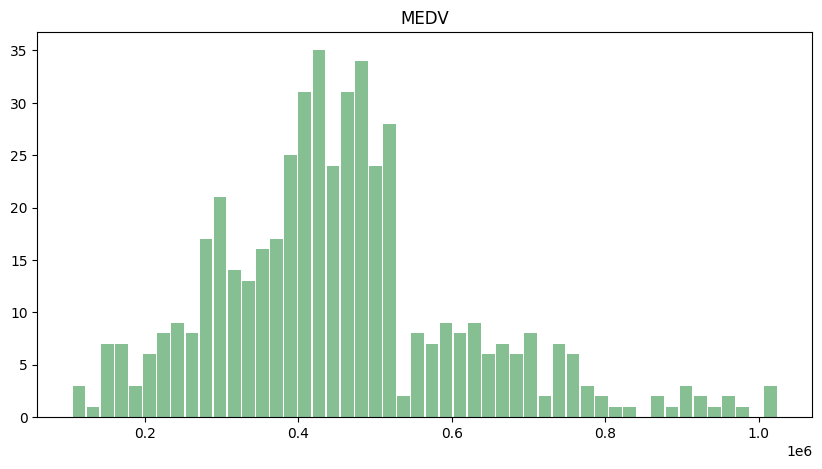

In [345]:
import matplotlib.pyplot as plt
histogram = df.hist('MEDV', bins=50, grid=False, figsize=(10, 5), color='#86bf91', zorder=2, rwidth=0.9,)

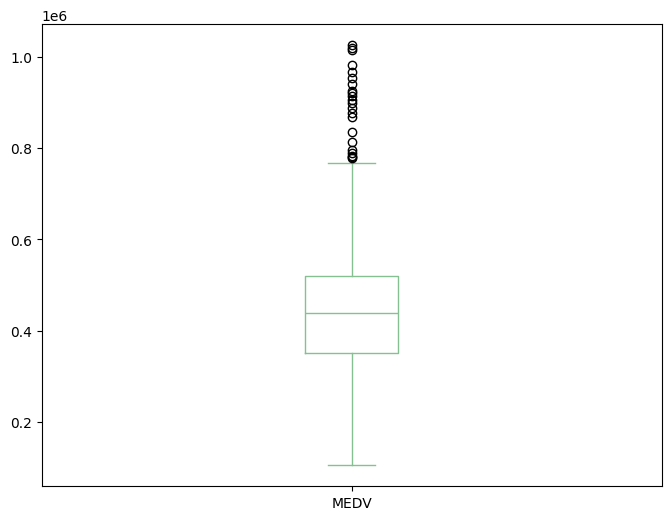

In [346]:
box=df.boxplot(column='MEDV', grid=False, figsize=(8, 6), color='#86bf91', zorder=2)

<Axes: xlabel='LSTAT', ylabel='MEDV'>

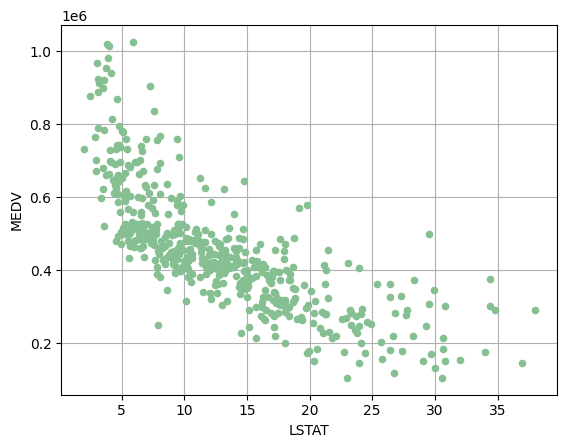

In [347]:
df.plot.scatter(x='LSTAT', y='MEDV', grid=True,  color='#86bf91', zorder=2)
#There is a strong negative correlation between LSTAT and MEDV, meaning that as the percentage of lower-status population increases, the median value of homes decreases.

<Axes: xlabel='RM', ylabel='MEDV'>

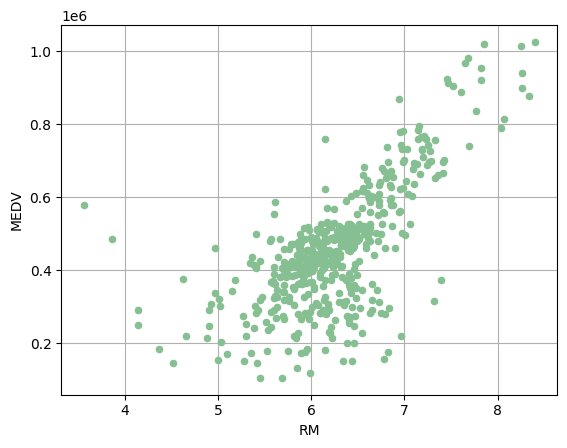

In [348]:
df.plot.scatter(x='RM', y='MEDV', grid=True,  color='#86bf91', zorder=2)
#no of rooms per dwelling (RM) is positively correlated with the median value of homes (MEDV). As the number of rooms increases, the median value of homes tends to increase as well.

<Axes: xlabel='PTRATIO', ylabel='MEDV'>

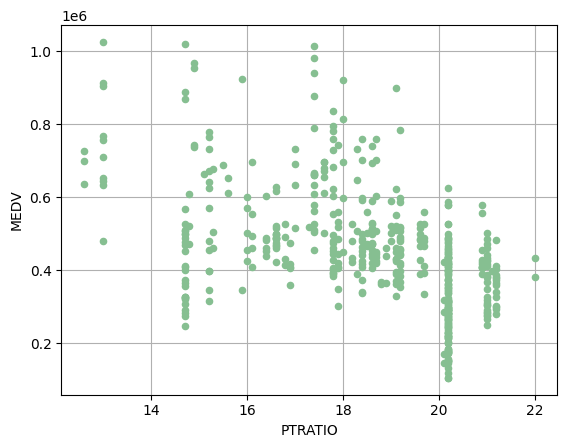

In [349]:
df.plot.scatter(x='PTRATIO', y='MEDV', grid=True,  color='#86bf91', zorder=2)
#PTRATIO = Pupil-Teacher Ratio
#There is a weak negative correlation between PTRATIO and MEDV, indicating that areas with a lower pupil-teacher ratio tend to have slightly higher home values.   

In [350]:
corre=df.corr()
corre
#The correlation matrix shows that home values (MEDV) have a strong positive correlation with the number of 
# rooms (RM), a strong negative correlation with the percentage of lower-status population 
# (LSTAT), and a moderate negative correlation with the pupil-teacher ratio (PTRATIO

,RM,LSTAT,PTRATIO,MEDV
RM,1.000000,-0.612033,-0.304559,0.697209
LSTAT,-0.612033,1.000000,0.360445,-0.760670
PTRATIO,-0.304559,0.360445,1.000000,-0.519034
MEDV,0.697209,-0.760670,-0.519034,1.000000


<Axes: >

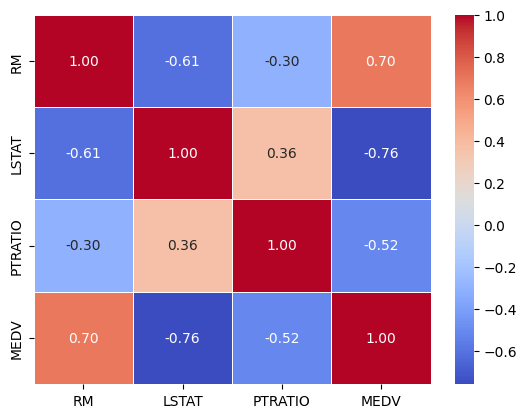

In [351]:
import seaborn as sns
sns.heatmap(corre, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

In [352]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [353]:
#Baseline: A simple reference model used to measure how much value our ML models add.
#In regression, a simple baseline predicts the mean of y_train for every sample. human predictions are often used as a baseline for regression problems. In this case, the baseline is the mean of the target variable (MEDV) in the training set. This means that if we were to predict the median value of homes for every sample in the test set, we would use the mean of y_train as our prediction.
baseline = y_train.mean()
baseline  #reference

np.float64(461758.3120204604)

In [ ]:
#linear regression model

In [354]:
from sklearn.linear_model import LinearRegression

Linear_Regression = LinearRegression()
#Can the relationship between the features and the price be approximately represented as a linear relationship?

In [355]:
Linear_Regression.fit(x_train, y_train)#This is exactly where the model starts learning.
#hat{y}=b_0+b_1RM+b_2LSTAT+b_3PTRATIO
    

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [400]:
y_pred_lr=Linear_Regression.predict(x_test)
y_train_pred_lr = Linear_Regression.predict(x_train)
train_r2_lr = r2_score(y_train, y_train_pred_lr)

In [357]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae_lr=mean_absolute_error(y_test, y_pred_lr)
mse_lr=mean_squared_error(y_test, y_pred_lr)
rmse_lr=np.sqrt(mse_lr) 
r2_lr=r2_score(y_test, y_pred_lr)
print("Mean Absolute Error (MAE):", mae_lr)
print("Mean Squared Error (MSE):", mse_lr)
print("Root Mean Squared Error (RMSE):", rmse_lr)
print("R-squared (R2):", r2_lr)


Mean Absolute Error (MAE): 64277.28865670342
Mean Squared Error (MSE): 6789025559.265895
Root Mean Squared Error (RMSE): 82395.54332162568
R-squared (R2): 0.6910934003098509


In [ ]:
#ridge regression model

In [358]:
#Does adding regularization make the model more stable and improve its performance on new data?
from sklearn.linear_model import Ridge, Lasso
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train, y_train)
y_pred_ridge = ridge_model.predict(x_test)

In [359]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MAE:", mae_ridge)
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R²:", r2_ridge)

MAE: 64290.75572284624
MSE: 6787779698.3772955
RMSE: 82387.98273035513
R²: 0.6911500880697399


In [ ]:
#complixity analysis for ridge regression model

In [391]:
alphas = [0.01, 0.1, 1, 10, 100]
train_r2_scores_ridge = []
test_r2_scores_ridge = []
for alpha in alphas:

    ridge_model = Ridge(alpha=alpha)

    ridge_model.fit(x_train, y_train)

    y_train_pred = ridge_model.predict(x_train)
    y_test_pred = ridge_model.predict(x_test)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    train_r2_scores_ridge.append(r2_train)
    test_r2_scores_ridge.append(r2_test)

In [392]:
results_ridge = pd.DataFrame({
    "Alpha": alphas,
    "Train R²": train_r2_scores_ridge,
    "Test R²": test_r2_scores_ridge
})

results_ridge

,Alpha,Train R²,Test R²
0,0.01,0.719453,0.691094
1,0.10,0.719453,0.691100
2,1.00,0.719447,0.691150
3,10.00,0.718932,0.691240
4,100.00,0.702596,0.680608


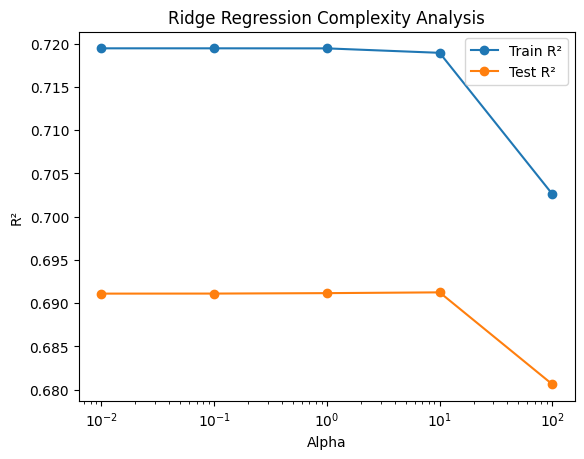

In [393]:
plt.plot(
    alphas,
    train_r2_scores_ridge,
    marker="o",
    label="Train R²"
)

plt.plot(
    alphas,
    test_r2_scores_ridge,
    marker="o",
    label="Test R²"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("Ridge Regression Complexity Analysis")

plt.legend()
plt.show()

In [ ]:
#Good Region: Occurs when Alpha values are small (ranging from $10^{-2}$ to $10^{1}$), where both training and test $R^2$ scores remain completely stable and at their highest optimal performance level.   Underfitting / High Regularization: Appears clearly on the far right at Alpha = 10^2 (100), where a sharp and sudden drop occurs in both train and test $R^2$ scores because the regularization penalty becomes too strong, overly constraining the coefficients and crippling the model's ability to learn.   Bias and Variance: For small Alpha values, variance is well-controlled and the model remains stable; however, increasing Alpha to $10^2$ causes High Bias to spike because the model is excessively restricted from capturing the true patterns in the data.   

In [ ]:
#lasso regression model

In [360]:
lasso_lr_model = Lasso(alpha=0.1)
lasso_lr_model.fit(x_train, y_train)
lasso_lr_pred = lasso_lr_model.predict(x_test)

In [361]:
mae_lr_lasso = mean_absolute_error(y_test, lasso_lr_pred)
mse_lr_lasso = mean_squared_error(y_test, lasso_lr_pred)
rmse_lr_lasso = np.sqrt(mse_lr_lasso)
r2_lr_lasso = r2_score(y_test, lasso_lr_pred)

print("MAE:", mae_lr_lasso)
print("MSE:", mse_lr_lasso)
print("RMSE:", rmse_lr_lasso)
print("R²:", r2_lr_lasso)

MAE: 64277.29776115269
MSE: 6789025426.570426
RMSE: 82395.54251639117
R²: 0.6910934063476109


In [ ]:
#complixity analysis for lasso regression model

In [394]:
alphas = [0.01, 0.1, 1, 10, 100]

train_r2_scores_lasso = []
test_r2_scores_lasso = []

for alpha in alphas:

    lasso_model = Lasso(alpha=alpha)

    lasso_model.fit(x_train, y_train)

    y_train_pred = lasso_model.predict(x_train)
    y_test_pred = lasso_model.predict(x_test)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    train_r2_scores_lasso.append(r2_train)
    test_r2_scores_lasso.append(r2_test)

results_lasso = pd.DataFrame({
    "Alpha": alphas,
    "Train R²": train_r2_scores_lasso,
    "Test R²": test_r2_scores_lasso
})

results_lasso

,Alpha,Train R²,Test R²
0,0.01,0.719453,0.691093
1,0.10,0.719453,0.691093
2,1.00,0.719453,0.691093
3,10.00,0.719453,0.691095
4,100.00,0.719452,0.691104


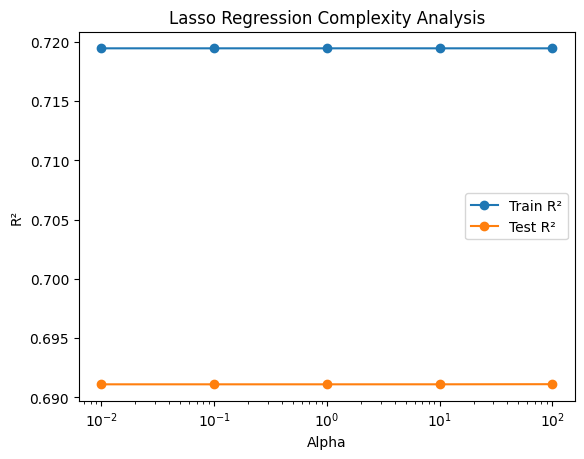

In [395]:
plt.plot(
    alphas,
    train_r2_scores_lasso,
    marker="o",
    label="Train R²"
)

plt.plot(
    alphas,
    test_r2_scores_lasso,
    marker="o",
    label="Test R²"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("Lasso Regression Complexity Analysis")

plt.legend()
plt.show()

In [ ]:
#Performance Stability: Both train and test $R^2$ scores remain completely flat and constant across all Alpha values (ranging from $10^{-2}$ to $10^2$).   Constant Behavior: Changing the regularization strength (Alpha) within this spectrum does not alter the model's performance or coefficients significantly.   Bias and Variance: Both bias and variance remain entirely stable across the board because the model's effective complexity and feature selection do not fluctuate with these specific Alpha choices

In [362]:
#polynomial regression without scaling

In [363]:
#Polynomial Regression : Does the relationship between the features and the target require non-linear complexity?
from numpy import poly
from sklearn.preprocessing import PolynomialFeatures
poly_model=PolynomialFeatures(degree=2)
#y=b_0+b_1RM+b_2LSTAT+b_3RM^2+b_4(RM\times LSTAT)+b_5LSTAT^2
x_train_poly = poly_model.fit_transform(x_train)#It means: learn + transform.
x_test_poly = poly_model.transform(x_test)
#So why doesn't the test set fit?
#Because the test set must undergo the same transformation applied to the training set.
#        X
#        ↓
# PolynomialFeatures
#        ↓
#    [1, X, X²]
poly_model=LinearRegression()
poly_model.fit(x_train_poly, y_train)#train the model on the polynomial features of the training set
y_pred_poly=poly_model.predict(x_test_poly)#predict the target variable for the polynomial features of the test set

In [364]:

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("MAE:", mae_poly)
print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("R²:", r2_poly)
#Polynomial Regression is currently performing better than Linear Regression on the test set.

MAE: 49737.64090564841
MSE: 3992883256.094275
RMSE: 63189.26535491827
R²: 0.8183203202238076


In [365]:
#Does adding regularization make the model more stable and improve its performance on new data?
from sklearn.linear_model import Ridge, Lasso
ridge_poly_model = Ridge(alpha=1.0)
ridge_poly_model.fit(x_train_poly, y_train)
y_pred_poly_ridge = ridge_poly_model.predict(x_test_poly)

In [366]:
mae_poly_ridge = mean_absolute_error(y_test, y_pred_poly_ridge)
mse_poly_ridge = mean_squared_error(y_test, y_pred_poly_ridge)
rmse_poly_ridge = np.sqrt(mse_poly_ridge)
r2_poly_ridge = r2_score(y_test, y_pred_poly_ridge)

print("MAE:", mae_poly_ridge)
print("MSE:", mse_poly_ridge)
print("RMSE:", rmse_poly_ridge)
print("R²:", r2_poly_ridge)

MAE: 49470.25725206351
MSE: 4034767775.571069
RMSE: 63519.82191073168
R²: 0.8164145379612009


In [367]:
lasso_poly_model = Lasso(alpha=0.1)
lasso_poly_model.fit(x_train_poly, y_train)
lasso_poly_pred = lasso_poly_model.predict(x_test_poly)

c:\Users\zbook g8\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.093e+11, tolerance: 1.108e+09
  model = cd_fast.enet_coordinate_descent(


In [368]:
mae_poly_lasso = mean_absolute_error(y_test, lasso_poly_pred)
mse_poly_lasso = mean_squared_error(y_test, lasso_poly_pred)
rmse_poly_lasso = np.sqrt(mse_poly_lasso)
r2_poly_lasso = r2_score(y_test, lasso_poly_pred)

print("MAE:", mae_poly_lasso)
print("MSE:", mse_poly_lasso)
print("RMSE:", rmse_poly_lasso)
print("R²:", r2_poly_lasso)

MAE: 48832.4925499965
MSE: 3982009815.411653
RMSE: 63103.168029914734
R²: 0.8188150712832755


In [369]:
y_train_pred_poly = poly_model.predict(x_train_poly)

In [370]:
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, y_train_pred_poly)
test_r2 = r2_score(y_test, y_pred_poly)
print("Train R²:", train_r2)
print("Test R²:", test_r2)
#there is no overfitting in the polynomial regression model

Train R²: 0.8378254104692311
Test R²: 0.8183203202238076


In [371]:
#poly reg with scaling

In [372]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

scaler = StandardScaler()

X_train_poly_scaled = scaler.fit_transform(x_train_poly)
X_test_poly_scaled = scaler.transform(x_test_poly)

In [373]:
ridge_poly = Ridge(alpha=1.0)

ridge_poly.fit(X_train_poly_scaled, y_train)

y_pred_ridge_poly = ridge_poly.predict(X_test_poly_scaled)

In [374]:
mae_ridge_poly_scaled = mean_absolute_error(y_test, y_pred_ridge_poly)
mse_ridge_poly_scaled = mean_squared_error(y_test, y_pred_ridge_poly)
rmse_ridge_poly_scaled = np.sqrt(mse_ridge_poly_scaled)
r2_ridge_poly_scaled = r2_score(y_test, y_pred_ridge_poly)

print("MAE:", mae_ridge_poly_scaled)
print("MSE:", mse_ridge_poly_scaled)
print("RMSE:", rmse_ridge_poly_scaled)
print("R²:", r2_ridge_poly_scaled)

MAE: 51419.55011369526
MSE: 4410523073.65533
RMSE: 66411.76908993864
R²: 0.7993173433147105


In [375]:
lasso_poly = Lasso(alpha=1.0)

lasso_poly.fit(X_train_poly_scaled, y_train)

y_pred_lasso_poly = lasso_poly.predict(X_test_poly_scaled)

c:\Users\zbook g8\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.004e+11, tolerance: 1.108e+09
  model = cd_fast.enet_coordinate_descent(


In [376]:
mae_lasso_poly_scaled = mean_absolute_error(y_test, y_pred_lasso_poly)
mse_lasso_poly_scaled = mean_squared_error(y_test, y_pred_lasso_poly)
rmse_lasso_poly_scaled = np.sqrt(mse_lasso_poly_scaled)
r2_lasso_poly_scaled = r2_score(y_test, y_pred_lasso_poly)

print("MAE:", mae_lasso_poly_scaled)
print("MSE:", mse_lasso_poly_scaled)
print("RMSE:", rmse_lasso_poly_scaled)
print("R²:", r2_lasso_poly_scaled)

MAE: 48840.354966948464
MSE: 3983427726.0749984
RMSE: 63114.4018911294
R²: 0.8187505551081845


In [377]:
print(lasso_poly.coef_)

[      0.          -27097.71420329  226744.71841813  259149.64273693
  280020.26275906 -173212.39964137 -196596.4850824     -855.48526508
 -125129.39254333  -91153.39218751]


In [ ]:
#complexity analysis for polynomial model

In [387]:
degrees = range(1, 6)
train_r2_scores_poly = []
test_r2_scores_poly = []
for degree in degrees:

    poly_model = PolynomialFeatures(degree=degree)

    x_train_poly = poly_model.fit_transform(x_train)
    x_test_poly = poly_model.transform(x_test)

    model = LinearRegression()

    model.fit(x_train_poly, y_train)

    y_train_pred = model.predict(x_train_poly)
    y_test_pred = model.predict(x_test_poly)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    train_r2_scores_poly.append(r2_train)
    test_r2_scores_poly.append(r2_test)


In [388]:
results_poly = pd.DataFrame({
    "Degree": list(degrees),
    "Train R²": train_r2_scores_poly,
    "Test R²": test_r2_scores_poly
})

results_poly

,Degree,Train R²,Test R²
0,1,0.719453,0.691093
1,2,0.837825,0.818320
2,3,0.847851,0.822272
3,4,0.862321,0.837688
4,5,0.876912,0.843955


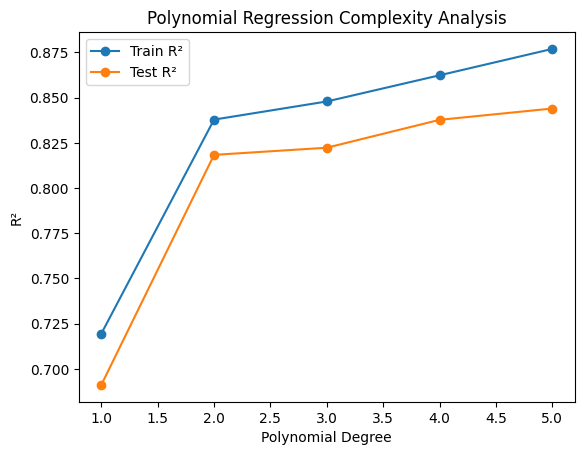

In [390]:
plt.plot(
    list(degrees),
    train_r2_scores_poly,
    marker="o",
    label="Train R²"
)

plt.plot(
    list(degrees),
    test_r2_scores_poly,
    marker="o",
    label="Test R²"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R²")
plt.title("Polynomial Regression Complexity Analysis")

plt.legend()
plt.show()

In [ ]:
#Underfitting: Occurs at Polynomial Degree = 1, where both train and test $R^2$ values are at their lowest (around 0.72 and 0.69), reflecting a very simple model (a straight line) that fails to capture the data complexities.   Good Region: Located at Polynomial Degree = 2 (or 3), where a significant and optimal jump occurs, raising the test $R^2$ value to around 0.82 with a very small gap between training and testing.   Overfitting: As the polynomial degree increases toward Degree = 4 and 5, train $R^2$ continues to rise slowly while test $R^2$ stabilizes or plateaus around 0.84, indicating that increasing complexity provides no real added value for testing.   High Bias: Clearly appears at the beginning of the curve at Degree = 1, where model performance is weak and low in both cases.   Variance: Starts increasing gradually as we move to the right (Degree = 4 and 5), accompanied by a slight widening of the distance between the train and test lines.   

In [378]:
#Decision Tree Regressor

In [379]:
from sklearn.tree import DecisionTreeRegressor
model_DecisionTree=DecisionTreeRegressor(max_depth=4,
    random_state=42)
model_DecisionTree.fit(x_train, y_train)
y_pred_tree=model_DecisionTree.predict(x_test)


In [380]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("MAE:", mae_tree)
print("MSE:", mse_tree)
print("RMSE:", rmse_tree)
print("R²:", r2_tree)

MAE: 45178.58426027458
MSE: 3428515260.6211796
RMSE: 58553.52474976361
R²: 0.8439995575360899


In [381]:
y_train_pred_tree = model_DecisionTree.predict(x_train)
r2_train_tree = r2_score(y_train, y_train_pred_tree)
r2_test_tree = r2_score(y_test, y_pred_tree)
print("Train R²:", r2_train_tree)
print("Test R²:", r2_test_tree)
#there is no overfitting in the Decision Tree Regressor model

Train R²: 0.8596208050871595
Test R²: 0.8439995575360899


In [ ]:
#Complexity Analysis for models -> decision tree 

In [383]:
depths = range(1, 11)
train_decision_tree_r2_scores = []
test_decision_tree_r2_scores = []
for depth in depths:

    model_DecisionTree = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model_DecisionTree.fit(x_train, y_train)

    y_train_pred_tree = model_DecisionTree.predict(x_train)
    y_test_pred_tree = model_DecisionTree.predict(x_test)

    r2_train_tree = r2_score(y_train, y_train_pred_tree)
    r2_test_tree = r2_score(y_test, y_test_pred_tree)

    train_decision_tree_r2_scores.append(r2_train_tree)
    test_decision_tree_r2_scores.append(r2_test_tree)

In [384]:
results_tree = pd.DataFrame({
    "max_depth": list(depths),
    "Train R²": train_decision_tree_r2_scores,
    "Test R²": test_decision_tree_r2_scores
})

results_tree

,max_depth,Train R²,Test R²
0,1,0.456514,0.324606
1,2,0.720510,0.681735
2,3,0.820043,0.767107
3,4,0.859621,0.844000
4,5,0.895696,0.824424
5,6,0.931052,0.811129
6,7,0.950171,0.794632
7,8,0.963874,0.770431
8,9,0.972948,0.765822
9,10,0.982154,0.752714


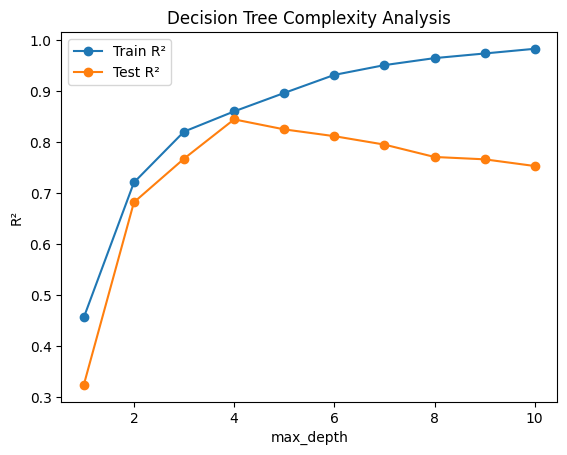

In [386]:
import matplotlib.pyplot as plt

plt.plot(
    list(depths),
    train_decision_tree_r2_scores,
    marker="o",
    label="Train R²"
)

plt.plot(
    list(depths),
    test_decision_tree_r2_scores,
    marker="o",
    label="Test R²"
)

plt.xlabel("max_depth")
plt.ylabel("R²")
plt.title("Decision Tree Complexity Analysis")

plt.legend()
plt.show()

In [ ]:
#Underfitting: Occurs at very low complexity levels (e.g., max_depth = 1 or 2), where both training and test scores are low because the model is too simple to capture underlying patterns.   Good Region: Found at the optimal complexity level (max_depth = 4), where the test score reaches its peak and the gap between training and test performance is minimal.   Overfitting: Emerges at high complexity levels (from max_depth = 5 to 10), where training score keeps increasing while the test score drops, creating a wide performance gap.   High Bias: Characterized on the left side of the plot by uniformly low scores on both training and test sets due to an overly simplistic model.   High Variance: Characterized on the right side of the plot by a massive gap where training performance is near-perfect and test performance drops due to extreme model sensitivity.   

In [407]:
comparison = pd.DataFrame({
    "Model": [
        "Linear",
        "Polynomial",
        "Ridge",
        "Lasso",
        "Decision Tree"
    ],

    "MAE": [
        mae_lr,
        mae_poly,
        mae_ridge,
        mae_lr_lasso,
        mae_tree
    ],

    "MSE": [
        mse_lr,
        mse_poly,
        mse_ridge,
        mse_lr_lasso,
        mse_tree
    ],

    "RMSE": [
        rmse_lr,
        rmse_poly,
        rmse_ridge,
        rmse_lr_lasso,
        rmse_tree
    ],


    "Test R²": [
        r2_lr,
        r2_poly,
        r2_ridge,
        r2_lr_lasso,
        r2_tree
    ]
})



comparison["Behavior"] = [
    "Linear relationship",
    "Non-linear relationship",
    "Regularized linear model",
    "Regularized linear model with feature selection",
    "Non-linear tree-based model"
]

comparison

,Model,MAE,MSE,RMSE,Test R²,Behavior
0,Linear,64277.288657,6.789026e+09,82395.543322,0.691093,Linear relationship
1,Polynomial,49737.640906,3.992883e+09,63189.265355,0.818320,Non-linear relationship
2,Ridge,64290.755723,6.787780e+09,82387.982730,0.691150,Regularized linear model
3,Lasso,64277.297761,6.789025e+09,82395.542516,0.691093,Regularized linear model with feature selection
4,Decision Tree,45178.584260,3.428515e+09,58553.524750,0.844000,Non-linear tree-based model
